In [1]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ==========================
# Settings
# ==========================
folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

temp_base_folder_default = r"Z:\Lab_HPT_logs\Open_air"
temp_base_folder_top_insensitive = r"Z:\Lab_HPT_logs\1762nm_box"

start_date = datetime(2026, 2, 17, 0, 0, 0)
end_date   = datetime(2026, 12, 15, 0, 0, 0)

USE_TOP_TEMP_FOR_B = False  # False -> Open_air, True -> 1762nm_box
TEMP_BIN_MINUTES = 5        # None, 1, or 5

GAP_THRESHOLD_MIN = 30      # if gap > this, compress it out of the x-axis

# ==========================
# Temperature loading (same as your script)
# ==========================
temp_line_pattern = re.compile(
    r"^(?P<time>\d{2}:\d{2}:\d{2})\s*-\s*.*?\bAvg Temp:\s*(?P<temp>[-+]?\d*\.?\d+)"
)
temperature_cache = {}

def load_temperature_for_day(day_dt, base_folder):
    cache_key = (base_folder, day_dt.date())
    if cache_key in temperature_cache:
        return temperature_cache[cache_key]

    month_dir = os.path.join(base_folder, day_dt.strftime("%Y_%m"))
    day_stem = day_dt.strftime("%Y_%m_%d")
    day_candidates = [
        os.path.join(month_dir, day_stem),
        os.path.join(month_dir, f"{day_stem}.txt"),
    ]

    day_file = next((path for path in day_candidates if os.path.isfile(path)), None)
    if day_file is None:
        temperature_cache[cache_key] = ([], [])
        return temperature_cache[cache_key]

    day_times, day_temps = [], []
    with open(day_file, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            match = temp_line_pattern.search(line.strip())
            if not match:
                continue
            try:
                sample_time = datetime.strptime(match.group("time"), "%H:%M:%S").time()
                sample_dt = datetime.combine(day_dt.date(), sample_time)
                sample_temp = float(match.group("temp"))
            except ValueError:
                continue
            day_times.append(sample_dt)
            day_temps.append(sample_temp)

    if day_times:
        paired = sorted(zip(day_times, day_temps), key=lambda x: x[0])
        day_times, day_temps = map(list, zip(*paired))

    temperature_cache[cache_key] = (day_times, day_temps)
    return temperature_cache[cache_key]

def load_temperature_series(start_dt, end_dt, base_folder):
    all_times, all_temps = [], []
    current_day = start_dt.date()
    last_day = end_dt.date()

    while current_day <= last_day:
        day_dt = datetime.combine(current_day, datetime.min.time())
        day_times, day_temps = load_temperature_for_day(day_dt, base_folder)
        for t, temp in zip(day_times, day_temps):
            if start_dt <= t <= end_dt:
                all_times.append(t)
                all_temps.append(temp)
        current_day += timedelta(days=1)

    return np.array(all_times, dtype=object), np.array(all_temps, dtype=float)

def bin_temperature_series(temp_times, temp_values, bin_minutes=None):
    if bin_minutes is None or temp_values.size == 0:
        return temp_times, temp_values
    if bin_minutes not in (1, 5):
        raise ValueError("TEMP_BIN_MINUTES must be None, 1, or 5")

    bins = {}
    for t, temp in zip(temp_times, temp_values):
        floored_minute = (t.minute // bin_minutes) * bin_minutes
        bin_dt = t.replace(minute=floored_minute, second=0, microsecond=0)
        bins.setdefault(bin_dt, []).append(float(temp))

    binned_times = sorted(bins.keys())
    binned_values = [np.mean(bins[bt]) for bt in binned_times]
    return np.array(binned_times, dtype=object), np.array(binned_values, dtype=float)

# ==========================
# B-field reading
# ==========================
def read_B_time_series(folder_paths, start_date, end_date):
    file_times, list_freqs = [], []

    for folder_path in folder_paths:
        if not os.path.isdir(folder_path):
            print(f"Skipping missing folder: {folder_path}")
            continue

        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            if not os.path.isfile(file_path):
                continue

            mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))
            if not (start_date <= mod_time <= end_date):
                continue

            with open(file_path, "r") as f:
                try:
                    lines = f.readlines()
                    top_list = json.loads(lines[0].strip())
                except (IndexError, json.JSONDecodeError):
                    continue

            if len(top_list) > 1:
                file_times.append(mod_time)
                list_freqs.append(top_list)

    if not file_times:
        return [], np.array([])

    times, freqs = zip(*sorted(zip(file_times, list_freqs), key=lambda x: x[0]))
    f0 = np.array([ff[0] for ff in freqs], dtype=float)
    f1 = np.array([ff[1] for ff in freqs], dtype=float)

    B = (f1 - f0) / (-3.498)
    B = 4.2095 + B - B[0]
    return list(times), B

def to_epoch_seconds(dts):
    return np.array([dt.timestamp() for dt in dts], dtype=float)

# ==========================
# Gap-compressed time axis
# ==========================
def compressed_time_axis(times_dt, gap_threshold_minutes=30):
    """
    Returns x (seconds) where gaps larger than threshold are removed (compressed out).
    Keeps only time where data exists.
    """
    t = to_epoch_seconds(times_dt)
    if len(t) == 0:
        return np.array([])

    gap_thr = gap_threshold_minutes * 60.0
    x = np.zeros_like(t)
    offset = 0.0
    x[0] = 0.0

    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        if dt > gap_thr:
            # compress out the "extra" time beyond the threshold
            offset += (dt - gap_thr)
        x[i] = (t[i] - t[0]) - offset

    return x

# ==========================
# Main
# ==========================
times_B, B = read_B_time_series(folder_paths, start_date, end_date)
print("Measured B points:", len(B))
if len(B) < 5:
    raise SystemExit("Not enough B points in date range.")

# Load temperature across the full B span
temp_folder = temp_base_folder_top_insensitive if USE_TOP_TEMP_FOR_B else temp_base_folder_default
temp_times, temp_vals = load_temperature_series(times_B[0], times_B[-1], temp_folder)
temp_times, temp_vals = bin_temperature_series(temp_times, temp_vals, TEMP_BIN_MINUTES)
print("Temperature points:", len(temp_vals))

# Interpolate temperature to B timestamps (safe direction)
if len(temp_vals) >= 2:
    tB = to_epoch_seconds(times_B)
    tT = to_epoch_seconds(list(temp_times))
    T_at_B = np.interp(tB, tT, temp_vals)
else:
    T_at_B = np.full(len(B), np.nan)

# Fit B = a + b*T and compute residual
mask = np.isfinite(T_at_B) & np.isfinite(B)
X = np.column_stack([np.ones(mask.sum()), T_at_B[mask]])
beta, *_ = np.linalg.lstsq(X, B[mask], rcond=None)
a, b = beta
B_fit = a + b * T_at_B
B_resid = B - B_fit

print(f"Fit: B ≈ a + b*T with a={a:.6g}, b={b:.6g} G/°C")

# Compressed time axis (seconds)
x = compressed_time_axis(times_B, GAP_THRESHOLD_MIN)

# ==========================
# Plot: 2 subplots, each with temperature
# ==========================
fig, ax = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# Top: raw B
ax[0].plot(x / 3600, B, "o-", markersize=3, linewidth=1, label="B raw")
ax[0].set_ylabel("B (G)")
ax[0].set_title("Raw B with Temperature (compressed time axis)")
ax[0].grid(True)

ax0t = ax[0].twinx()
ax0t.plot(x / 3600, T_at_B, "-", alpha=0.4, linewidth=1, label="Temp @ B times")
ax0t.set_ylabel("Temp (°C)")

# Bottom: residual
ax[1].plot(x / 3600, B_resid, "o-", markersize=3, linewidth=1, label="B residual (temp removed)")
ax[1].set_ylabel("Residual B (G)")
ax[1].set_title("B with temperature dependence removed (linear)")
ax[1].grid(True)

ax1t = ax[1].twinx()
ax1t.plot(x / 3600, T_at_B, "-", alpha=0.4, linewidth=1, label="Temp @ B times")
ax1t.set_ylabel("Temp (°C)")

ax[1].set_xlabel("Compressed time (hours)")

# Legends (combine left + right per subplot)
for i, axis in enumerate(ax):
    lines_l, labels_l = axis.get_legend_handles_labels()
    twin = axis.twinx()  # dummy to get handles? no—so we’ll grab from existing twins manually
plt.close(twin.figure)  # just in case; ignore

# Manually combine legends without creating new twins:
lines0, labels0 = ax[0].get_legend_handles_labels()
lines0t, labels0t = ax0t.get_legend_handles_labels()
ax[0].legend(lines0 + lines0t, labels0 + labels0t, loc="best")

lines1, labels1 = ax[1].get_legend_handles_labels()
lines1t, labels1t = ax1t.get_legend_handles_labels()
ax[1].legend(lines1 + lines1t, labels1 + labels1t, loc="best")

plt.tight_layout()
plt.savefig("B_raw_and_residual_compressed_time.png", dpi=200)
plt.show()

Measured B points: 712
Temperature points: 1674
Fit: B ≈ a + b*T with a=4.10718, b=0.0046853 G/°C


<Figure size 640x480 with 0 Axes>

Measured B points: 712
Fit: B ≈ a + b*T with a=4.10718, b=0.0046853 G/°C


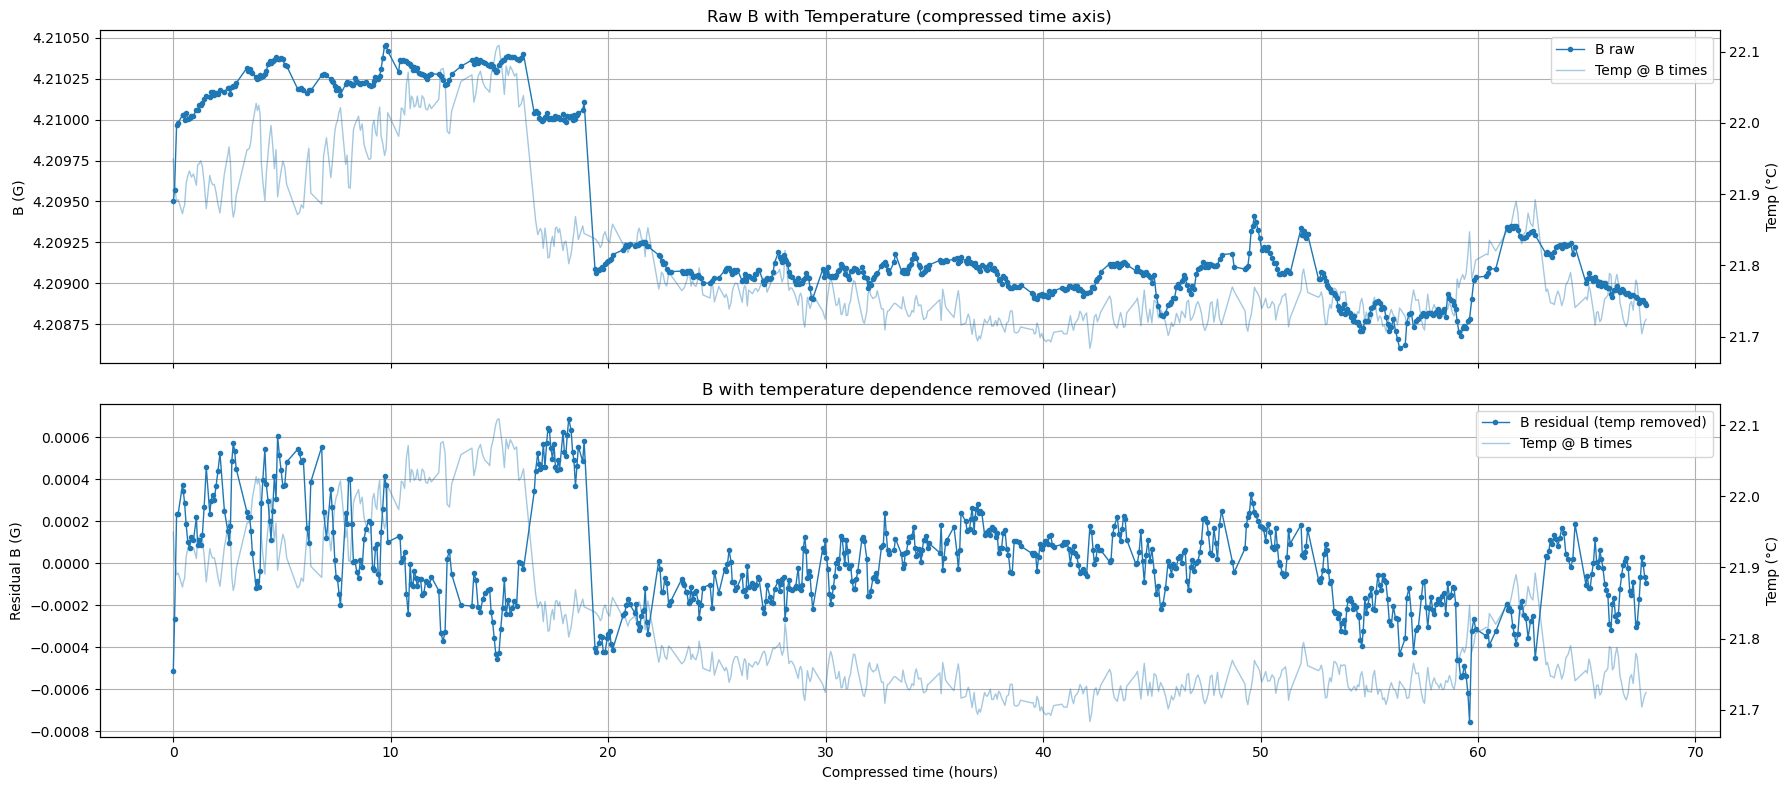

In [2]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# If you're in a notebook, you may want this:
# %matplotlib inline

folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

temp_base_folder_default = r"Z:\Lab_HPT_logs\Open_air"
temp_base_folder_top_insensitive = r"Z:\Lab_HPT_logs\1762nm_box"

start_date = datetime(2026, 2, 17, 0, 0, 0)
end_date   = datetime(2026, 12, 15, 0, 0, 0)

USE_TOP_TEMP_FOR_B = False
TEMP_BIN_MINUTES = 5
GAP_THRESHOLD_MIN = 30

temp_line_pattern = re.compile(
    r"^(?P<time>\d{2}:\d{2}:\d{2})\s*-\s*.*?\bAvg Temp:\s*(?P<temp>[-+]?\d*\.?\d+)"
)
temperature_cache = {}

def load_temperature_for_day(day_dt, base_folder):
    cache_key = (base_folder, day_dt.date())
    if cache_key in temperature_cache:
        return temperature_cache[cache_key]

    month_dir = os.path.join(base_folder, day_dt.strftime("%Y_%m"))
    day_stem = day_dt.strftime("%Y_%m_%d")
    day_candidates = [
        os.path.join(month_dir, day_stem),
        os.path.join(month_dir, f"{day_stem}.txt"),
    ]

    day_file = next((path for path in day_candidates if os.path.isfile(path)), None)
    if day_file is None:
        temperature_cache[cache_key] = ([], [])
        return temperature_cache[cache_key]

    day_times, day_temps = [], []
    with open(day_file, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            match = temp_line_pattern.search(line.strip())
            if not match:
                continue
            try:
                sample_time = datetime.strptime(match.group("time"), "%H:%M:%S").time()
                sample_dt = datetime.combine(day_dt.date(), sample_time)
                sample_temp = float(match.group("temp"))
            except ValueError:
                continue
            day_times.append(sample_dt)
            day_temps.append(sample_temp)

    if day_times:
        paired = sorted(zip(day_times, day_temps), key=lambda x: x[0])
        day_times, day_temps = map(list, zip(*paired))

    temperature_cache[cache_key] = (day_times, day_temps)
    return temperature_cache[cache_key]

def load_temperature_series(start_dt, end_dt, base_folder):
    all_times, all_temps = [], []
    current_day = start_dt.date()
    last_day = end_dt.date()
    while current_day <= last_day:
        day_dt = datetime.combine(current_day, datetime.min.time())
        day_times, day_temps = load_temperature_for_day(day_dt, base_folder)
        for t, temp in zip(day_times, day_temps):
            if start_dt <= t <= end_dt:
                all_times.append(t)
                all_temps.append(temp)
        current_day += timedelta(days=1)
    return np.array(all_times, dtype=object), np.array(all_temps, dtype=float)

def bin_temperature_series(temp_times, temp_values, bin_minutes=None):
    if bin_minutes is None or temp_values.size == 0:
        return temp_times, temp_values
    if bin_minutes not in (1, 5):
        raise ValueError("TEMP_BIN_MINUTES must be None, 1, or 5")

    bins = {}
    for t, temp in zip(temp_times, temp_values):
        floored_minute = (t.minute // bin_minutes) * bin_minutes
        bin_dt = t.replace(minute=floored_minute, second=0, microsecond=0)
        bins.setdefault(bin_dt, []).append(float(temp))

    binned_times = sorted(bins.keys())
    binned_values = [np.mean(bins[bt]) for bt in binned_times]
    return np.array(binned_times, dtype=object), np.array(binned_values, dtype=float)

def read_B_time_series(folder_paths, start_date, end_date):
    file_times, list_freqs = [], []
    for folder_path in folder_paths:
        if not os.path.isdir(folder_path):
            print(f"Skipping missing folder: {folder_path}")
            continue
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            if not os.path.isfile(file_path):
                continue
            mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))
            if not (start_date <= mod_time <= end_date):
                continue
            with open(file_path, "r") as f:
                try:
                    lines = f.readlines()
                    top_list = json.loads(lines[0].strip())
                except (IndexError, json.JSONDecodeError):
                    continue
            if len(top_list) > 1:
                file_times.append(mod_time)
                list_freqs.append(top_list)

    if not file_times:
        return [], np.array([])

    times, freqs = zip(*sorted(zip(file_times, list_freqs), key=lambda x: x[0]))
    f0 = np.array([ff[0] for ff in freqs], dtype=float)
    f1 = np.array([ff[1] for ff in freqs], dtype=float)

    B = (f1 - f0) / (-3.498)
    B = 4.2095 + B - B[0]
    return list(times), B

def to_epoch_seconds(dts):
    return np.array([dt.timestamp() for dt in dts], dtype=float)

def compressed_time_axis(times_dt, gap_threshold_minutes=30):
    t = to_epoch_seconds(times_dt)
    if len(t) == 0:
        return np.array([])
    gap_thr = gap_threshold_minutes * 60.0
    x = np.zeros_like(t)
    offset = 0.0
    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        if dt > gap_thr:
            offset += (dt - gap_thr)
        x[i] = (t[i] - t[0]) - offset
    return x

# ---- run ----
times_B, B = read_B_time_series(folder_paths, start_date, end_date)
print("Measured B points:", len(B))
if len(B) < 5:
    raise SystemExit("Not enough B points in date range.")

temp_folder = temp_base_folder_top_insensitive if USE_TOP_TEMP_FOR_B else temp_base_folder_default
temp_times, temp_vals = load_temperature_series(times_B[0], times_B[-1], temp_folder)
temp_times, temp_vals = bin_temperature_series(temp_times, temp_vals, TEMP_BIN_MINUTES)

if len(temp_vals) >= 2:
    tB = to_epoch_seconds(times_B)
    tT = to_epoch_seconds(list(temp_times))
    T_at_B = np.interp(tB, tT, temp_vals)
else:
    T_at_B = np.full(len(B), np.nan)

mask = np.isfinite(T_at_B) & np.isfinite(B)
X = np.column_stack([np.ones(mask.sum()), T_at_B[mask]])
beta, *_ = np.linalg.lstsq(X, B[mask], rcond=None)
a, b = beta
B_fit = a + b * T_at_B
B_resid = B - B_fit

print(f"Fit: B ≈ a + b*T with a={a:.6g}, b={b:.6g} G/°C")

x = compressed_time_axis(times_B, GAP_THRESHOLD_MIN)

fig, ax = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

ax[0].plot(x/3600, B, "o-", markersize=3, linewidth=1, label="B raw")
ax[0].set_ylabel("B (G)")
ax[0].set_title("Raw B with Temperature (compressed time axis)")
ax[0].grid(True)
ax0t = ax[0].twinx()
ax0t.plot(x/3600, T_at_B, "-", alpha=0.4, linewidth=1, label="Temp @ B times")
ax0t.set_ylabel("Temp (°C)")

ax[1].plot(x/3600, B_resid, "o-", markersize=3, linewidth=1, label="B residual (temp removed)")
ax[1].set_ylabel("Residual B (G)")
ax[1].set_title("B with temperature dependence removed (linear)")
ax[1].grid(True)
ax1t = ax[1].twinx()
ax1t.plot(x/3600, T_at_B, "-", alpha=0.4, linewidth=1, label="Temp @ B times")
ax1t.set_ylabel("Temp (°C)")
ax[1].set_xlabel("Compressed time (hours)")

# Correct legend combining (no dummy axes, no closing figure)
lines0, labels0 = ax[0].get_legend_handles_labels()
lines0t, labels0t = ax0t.get_legend_handles_labels()
ax[0].legend(lines0 + lines0t, labels0 + labels0t, loc="best")

lines1, labels1 = ax[1].get_legend_handles_labels()
lines1t, labels1t = ax1t.get_legend_handles_labels()
ax[1].legend(lines1 + lines1t, labels1 + labels1t, loc="best")

plt.tight_layout()
plt.show()

Measured B points: 713
Temperature points: 1675
Fit done. Intercept a=4.07384
Dominant |b_k| at lag ≈ 120.0 min  (b=0.00173283 G/°C)
Model uses 25 lag terms from 0.0 to 120.0 minutes.


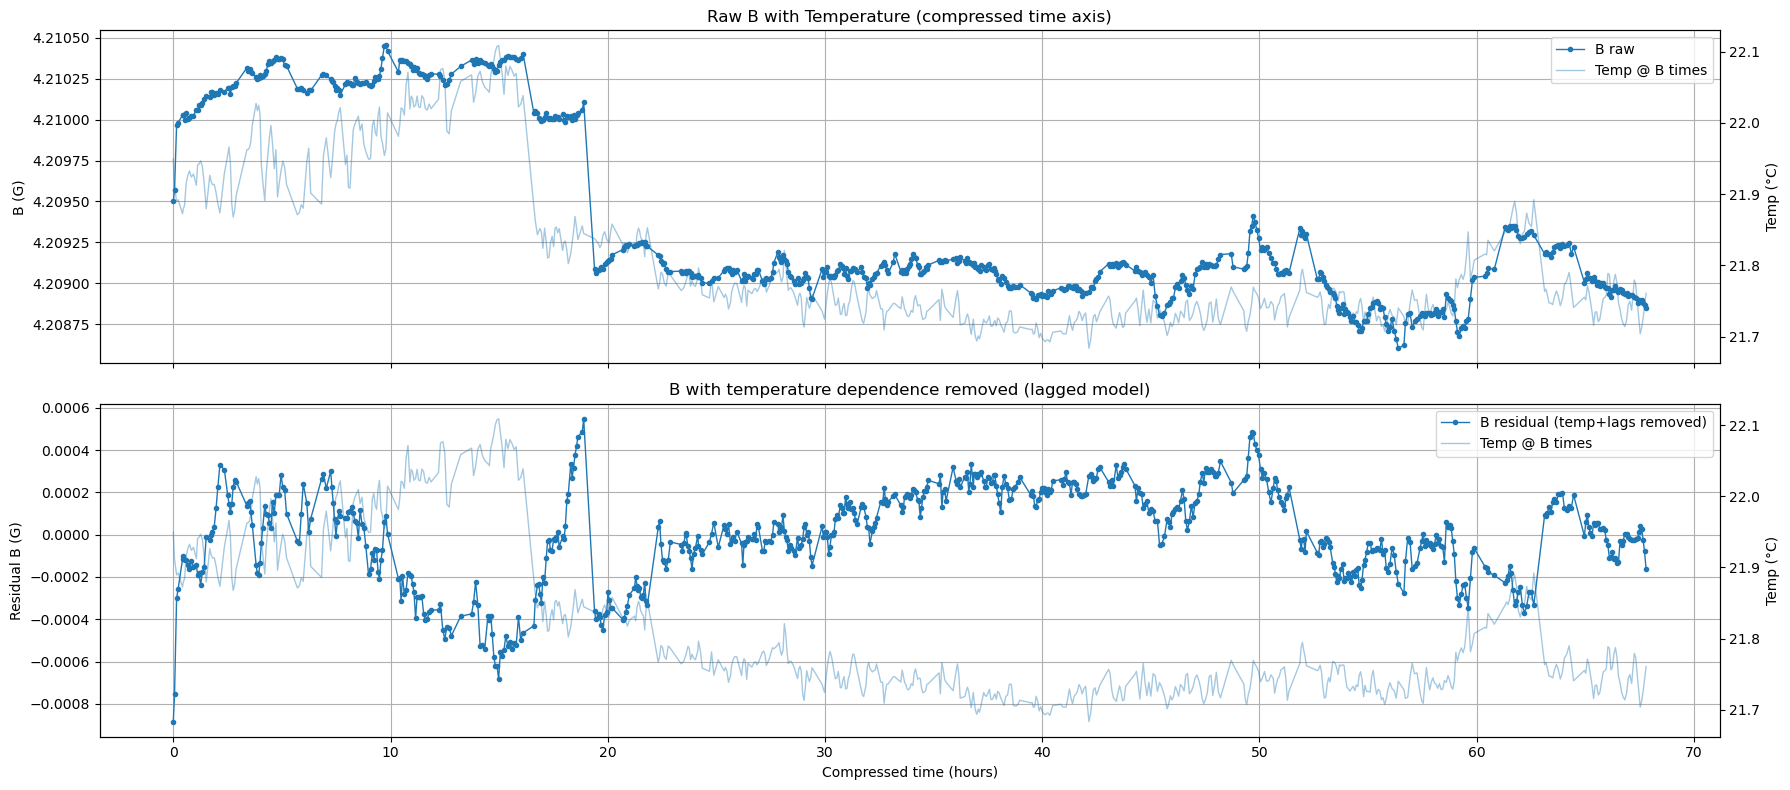

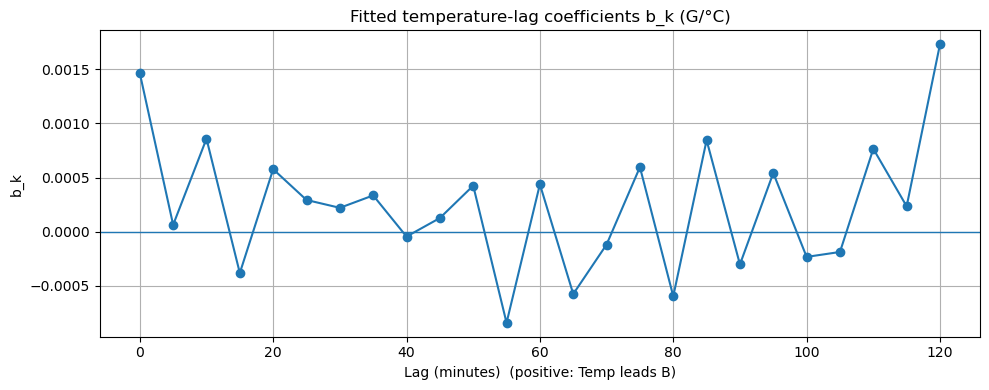

In [3]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ==========================
# Settings
# ==========================
folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

temp_base_folder_default = r"Z:\Lab_HPT_logs\Open_air"
temp_base_folder_top_insensitive = r"Z:\Lab_HPT_logs\1762nm_box"

start_date = datetime(2026, 2, 17, 0, 0, 0)
end_date   = datetime(2026, 12, 15, 0, 0, 0)

USE_TOP_TEMP_FOR_B = False
TEMP_BIN_MINUTES = 5
GAP_THRESHOLD_MIN = 30

# --- Lag model knobs ---
LAG_STEP_MIN = 5        # Δ in minutes (should match your temp bin)
MAX_LAG_MIN  = 120      # K*Δ max lag window in minutes
RIDGE_LAMBDA = 1e-4     # small regularization; increase if fit gets noisy/unstable

# Optional: allow also *positive* lags (Temp after B) for diagnosis
# Usually you expect Temp -> B, so only nonnegative lags are used in the fit.
USE_NEGATIVE_LAGS = False
NEG_LAG_MIN = 30  # only used if USE_NEGATIVE_LAGS=True

# ==========================
# Temperature loading (same as your script)
# ==========================
temp_line_pattern = re.compile(
    r"^(?P<time>\d{2}:\d{2}:\d{2})\s*-\s*.*?\bAvg Temp:\s*(?P<temp>[-+]?\d*\.?\d+)"
)
temperature_cache = {}

def load_temperature_for_day(day_dt, base_folder):
    cache_key = (base_folder, day_dt.date())
    if cache_key in temperature_cache:
        return temperature_cache[cache_key]

    month_dir = os.path.join(base_folder, day_dt.strftime("%Y_%m"))
    day_stem = day_dt.strftime("%Y_%m_%d")
    day_candidates = [
        os.path.join(month_dir, day_stem),
        os.path.join(month_dir, f"{day_stem}.txt"),
    ]

    day_file = next((path for path in day_candidates if os.path.isfile(path)), None)
    if day_file is None:
        temperature_cache[cache_key] = ([], [])
        return temperature_cache[cache_key]

    day_times, day_temps = [], []
    with open(day_file, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            match = temp_line_pattern.search(line.strip())
            if not match:
                continue
            try:
                sample_time = datetime.strptime(match.group("time"), "%H:%M:%S").time()
                sample_dt = datetime.combine(day_dt.date(), sample_time)
                sample_temp = float(match.group("temp"))
            except ValueError:
                continue
            day_times.append(sample_dt)
            day_temps.append(sample_temp)

    if day_times:
        paired = sorted(zip(day_times, day_temps), key=lambda x: x[0])
        day_times, day_temps = map(list, zip(*paired))

    temperature_cache[cache_key] = (day_times, day_temps)
    return temperature_cache[cache_key]

def load_temperature_series(start_dt, end_dt, base_folder):
    all_times, all_temps = [], []
    current_day = start_dt.date()
    last_day = end_dt.date()
    while current_day <= last_day:
        day_dt = datetime.combine(current_day, datetime.min.time())
        day_times, day_temps = load_temperature_for_day(day_dt, base_folder)
        for t, temp in zip(day_times, day_temps):
            if start_dt <= t <= end_dt:
                all_times.append(t)
                all_temps.append(temp)
        current_day += timedelta(days=1)
    return np.array(all_times, dtype=object), np.array(all_temps, dtype=float)

def bin_temperature_series(temp_times, temp_values, bin_minutes=None):
    if bin_minutes is None or temp_values.size == 0:
        return temp_times, temp_values
    if bin_minutes not in (1, 5):
        raise ValueError("TEMP_BIN_MINUTES must be None, 1, or 5")

    bins = {}
    for t, temp in zip(temp_times, temp_values):
        floored_minute = (t.minute // bin_minutes) * bin_minutes
        bin_dt = t.replace(minute=floored_minute, second=0, microsecond=0)
        bins.setdefault(bin_dt, []).append(float(temp))

    binned_times = sorted(bins.keys())
    binned_values = [np.mean(bins[bt]) for bt in binned_times]
    return np.array(binned_times, dtype=object), np.array(binned_values, dtype=float)

# ==========================
# B-field reading
# ==========================
def read_B_time_series(folder_paths, start_date, end_date):
    file_times, list_freqs = [], []
    for folder_path in folder_paths:
        if not os.path.isdir(folder_path):
            print(f"Skipping missing folder: {folder_path}")
            continue
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            if not os.path.isfile(file_path):
                continue
            mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))
            if not (start_date <= mod_time <= end_date):
                continue
            with open(file_path, "r") as f:
                try:
                    lines = f.readlines()
                    top_list = json.loads(lines[0].strip())
                except (IndexError, json.JSONDecodeError):
                    continue
            if len(top_list) > 1:
                file_times.append(mod_time)
                list_freqs.append(top_list)

    if not file_times:
        return [], np.array([])

    times, freqs = zip(*sorted(zip(file_times, list_freqs), key=lambda x: x[0]))
    f0 = np.array([ff[0] for ff in freqs], dtype=float)
    f1 = np.array([ff[1] for ff in freqs], dtype=float)

    B = (f1 - f0) / (-3.498)
    B = 4.2095 + B - B[0]
    return list(times), B

def to_epoch_seconds(dts):
    return np.array([dt.timestamp() for dt in dts], dtype=float)

def compressed_time_axis(times_dt, gap_threshold_minutes=30):
    t = to_epoch_seconds(times_dt)
    if len(t) == 0:
        return np.array([])
    gap_thr = gap_threshold_minutes * 60.0
    x = np.zeros_like(t)
    offset = 0.0
    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        if dt > gap_thr:
            offset += (dt - gap_thr)
        x[i] = (t[i] - t[0]) - offset
    return x

# ==========================
# Lagged temperature design matrix
# ==========================
def interp_temperature(temp_times, temp_vals, query_times_epoch):
    """Interpolate temperature values at arbitrary epoch seconds."""
    if len(temp_vals) < 2:
        return np.full_like(query_times_epoch, np.nan, dtype=float)
    tT = to_epoch_seconds(list(temp_times))
    return np.interp(query_times_epoch, tT, temp_vals)

def build_lagged_temp_matrix(times_B_epoch, temp_times, temp_vals,
                             lag_step_min, max_lag_min,
                             use_negative_lags=False, neg_lag_min=0):
    step_sec = lag_step_min * 60.0
    max_lag_sec = max_lag_min * 60.0

    if use_negative_lags:
        neg_sec = neg_lag_min * 60.0
        lags_sec = np.arange(-neg_sec, max_lag_sec + 0.1, step_sec)
    else:
        lags_sec = np.arange(0.0, max_lag_sec + 0.1, step_sec)

    # columns: intercept + T(t - lag)
    cols = [np.ones_like(times_B_epoch)]
    for lag in lags_sec:
        cols.append(interp_temperature(temp_times, temp_vals, times_B_epoch - lag))

    X = np.column_stack(cols)
    return X, lags_sec

def ridge_fit(X, y, lam):
    """Ridge regression: beta = (X^T X + lam I)^-1 X^T y"""
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    Xv = X[mask]
    yv = y[mask]
    if len(yv) < Xv.shape[1] + 5:
        return np.full_like(y, np.nan), np.full(X.shape[1], np.nan)

    XtX = Xv.T @ Xv
    reg = lam * np.eye(XtX.shape[0])
    beta = np.linalg.solve(XtX + reg, Xv.T @ yv)
    yhat = X @ beta
    return yhat, beta

# ==========================
# Main
# ==========================
times_B, B = read_B_time_series(folder_paths, start_date, end_date)
print("Measured B points:", len(B))
if len(B) < 10:
    raise SystemExit("Not enough B points in date range.")

temp_folder = temp_base_folder_top_insensitive if USE_TOP_TEMP_FOR_B else temp_base_folder_default
temp_times, temp_vals = load_temperature_series(times_B[0], times_B[-1], temp_folder)
temp_times, temp_vals = bin_temperature_series(temp_times, temp_vals, TEMP_BIN_MINUTES)
print("Temperature points:", len(temp_vals))

tB = to_epoch_seconds(times_B)

# Temperature at B timestamps (for plotting)
T_at_B = interp_temperature(temp_times, temp_vals, tB)

# Build lagged design matrix and fit
X, lags_sec = build_lagged_temp_matrix(
    tB, temp_times, temp_vals,
    lag_step_min=LAG_STEP_MIN,
    max_lag_min=MAX_LAG_MIN,
    use_negative_lags=USE_NEGATIVE_LAGS,
    neg_lag_min=NEG_LAG_MIN
)

B_fit, beta = ridge_fit(X, B, RIDGE_LAMBDA)
B_resid = B - B_fit

# beta structure: [a, b(lag0), b(lag1), ...]
a = beta[0]
b_lags = beta[1:]

# Report the "dominant lag" (where |b| is largest), excluding intercept
if np.all(np.isnan(b_lags)):
    print("Lag fit failed (not enough valid points).")
else:
    k = int(np.nanargmax(np.abs(b_lags)))
    dom_lag_min = lags_sec[k] / 60.0
    print(f"Fit done. Intercept a={a:.6g}")
    print(f"Dominant |b_k| at lag ≈ {dom_lag_min:.1f} min  (b={b_lags[k]:.6g} G/°C)")
    print(f"Model uses {len(b_lags)} lag terms from {lags_sec[0]/60:.1f} to {lags_sec[-1]/60:.1f} minutes.")

# Compressed time axis
x = compressed_time_axis(times_B, GAP_THRESHOLD_MIN)

# ==========================
# Plot: 2 subplots, each with temperature
# ==========================
fig, ax = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

ax[0].plot(x/3600, B, "o-", markersize=3, linewidth=1, label="B raw")
ax[0].set_ylabel("B (G)")
ax[0].set_title("Raw B with Temperature (compressed time axis)")
ax[0].grid(True)
ax0t = ax[0].twinx()
ax0t.plot(x/3600, T_at_B, "-", alpha=0.4, linewidth=1, label="Temp @ B times")
ax0t.set_ylabel("Temp (°C)")

ax[1].plot(x/3600, B_resid, "o-", markersize=3, linewidth=1, label="B residual (temp+lags removed)")
ax[1].set_ylabel("Residual B (G)")
ax[1].set_title("B with temperature dependence removed (lagged model)")
ax[1].grid(True)
ax1t = ax[1].twinx()
ax1t.plot(x/3600, T_at_B, "-", alpha=0.4, linewidth=1, label="Temp @ B times")
ax1t.set_ylabel("Temp (°C)")
ax[1].set_xlabel("Compressed time (hours)")

# Combine legends
lines0, labels0 = ax[0].get_legend_handles_labels()
lines0t, labels0t = ax0t.get_legend_handles_labels()
ax[0].legend(lines0 + lines0t, labels0 + labels0t, loc="best")

lines1, labels1 = ax[1].get_legend_handles_labels()
lines1t, labels1t = ax1t.get_legend_handles_labels()
ax[1].legend(lines1 + lines1t, labels1 + labels1t, loc="best")

plt.tight_layout()
plt.savefig("B_raw_and_residual_lagged_temp.png", dpi=200)
plt.show()

# Optional: plot lag coefficients (impulse response)
plt.figure(figsize=(10, 4))
plt.plot(lags_sec/60.0, b_lags, "o-")
plt.axhline(0, linewidth=1)
plt.title("Fitted temperature-lag coefficients b_k (G/°C)")
plt.xlabel("Lag (minutes)  (positive: Temp leads B)")
plt.ylabel("b_k")
plt.grid(True)
plt.tight_layout()
plt.show()

Measured B points: 714
Temperature points: 1676
Segments found: 20
Fitted segments: 17
Best segment fit: b=-0.00156803 G/°C, lag=30.0 min, R²=0.874


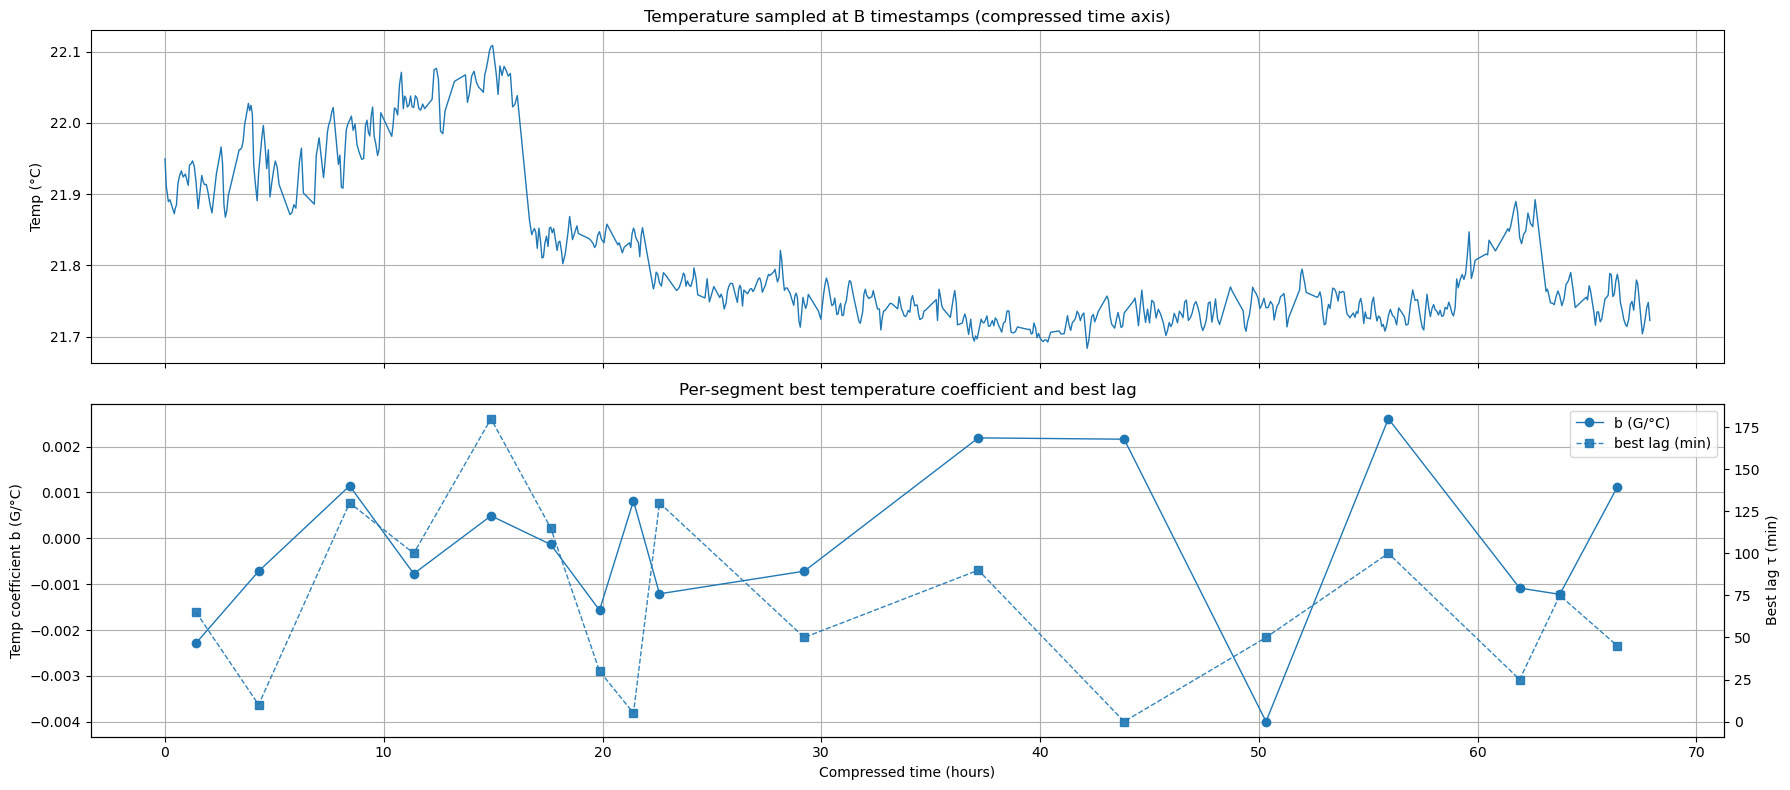

In [4]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ==========================
# Settings
# ==========================
folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

temp_base_folder_default = r"Z:\Lab_HPT_logs\Open_air"
temp_base_folder_top_insensitive = r"Z:\Lab_HPT_logs\1762nm_box"

start_date = datetime(2026, 2, 17, 0, 0, 0)
end_date   = datetime(2026, 12, 15, 0, 0, 0)

USE_TOP_TEMP_FOR_B = False
TEMP_BIN_MINUTES = 5

GAP_THRESHOLD_MIN = 30  # split segments if gap > this

# Lag scan per segment
LAG_STEP_MIN = 5
MAX_LAG_MIN  = 180      # scan 0..180 min (adjust)
MIN_POINTS_PER_SEGMENT = 8  # skip tiny segments

# ==========================
# Temperature loading helpers
# ==========================
temp_line_pattern = re.compile(
    r"^(?P<time>\d{2}:\d{2}:\d{2})\s*-\s*.*?\bAvg Temp:\s*(?P<temp>[-+]?\d*\.?\d+)"
)
temperature_cache = {}

def load_temperature_for_day(day_dt, base_folder):
    cache_key = (base_folder, day_dt.date())
    if cache_key in temperature_cache:
        return temperature_cache[cache_key]

    month_dir = os.path.join(base_folder, day_dt.strftime("%Y_%m"))
    day_stem = day_dt.strftime("%Y_%m_%d")
    day_candidates = [
        os.path.join(month_dir, day_stem),
        os.path.join(month_dir, f"{day_stem}.txt"),
    ]

    day_file = next((path for path in day_candidates if os.path.isfile(path)), None)
    if day_file is None:
        temperature_cache[cache_key] = ([], [])
        return temperature_cache[cache_key]

    day_times, day_temps = [], []
    with open(day_file, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            match = temp_line_pattern.search(line.strip())
            if not match:
                continue
            try:
                sample_time = datetime.strptime(match.group("time"), "%H:%M:%S").time()
                sample_dt = datetime.combine(day_dt.date(), sample_time)
                sample_temp = float(match.group("temp"))
            except ValueError:
                continue
            day_times.append(sample_dt)
            day_temps.append(sample_temp)

    if day_times:
        paired = sorted(zip(day_times, day_temps), key=lambda x: x[0])
        day_times, day_temps = map(list, zip(*paired))

    temperature_cache[cache_key] = (day_times, day_temps)
    return temperature_cache[cache_key]

def load_temperature_series(start_dt, end_dt, base_folder):
    all_times, all_temps = [], []
    current_day = start_dt.date()
    last_day = end_dt.date()
    while current_day <= last_day:
        day_dt = datetime.combine(current_day, datetime.min.time())
        day_times, day_temps = load_temperature_for_day(day_dt, base_folder)
        for t, temp in zip(day_times, day_temps):
            if start_dt <= t <= end_dt:
                all_times.append(t)
                all_temps.append(temp)
        current_day += timedelta(days=1)
    return np.array(all_times, dtype=object), np.array(all_temps, dtype=float)

def bin_temperature_series(temp_times, temp_values, bin_minutes=None):
    if bin_minutes is None or temp_values.size == 0:
        return temp_times, temp_values
    if bin_minutes not in (1, 5):
        raise ValueError("TEMP_BIN_MINUTES must be None, 1, or 5")

    bins = {}
    for t, temp in zip(temp_times, temp_values):
        floored_minute = (t.minute // bin_minutes) * bin_minutes
        bin_dt = t.replace(minute=floored_minute, second=0, microsecond=0)
        bins.setdefault(bin_dt, []).append(float(temp))

    binned_times = sorted(bins.keys())
    binned_values = [np.mean(bins[bt]) for bt in binned_times]
    return np.array(binned_times, dtype=object), np.array(binned_values, dtype=float)

# ==========================
# B-field reading
# ==========================
def read_B_time_series(folder_paths, start_date, end_date):
    file_times, list_freqs = [], []
    for folder_path in folder_paths:
        if not os.path.isdir(folder_path):
            print(f"Skipping missing folder: {folder_path}")
            continue
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            if not os.path.isfile(file_path):
                continue

            mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))
            if not (start_date <= mod_time <= end_date):
                continue

            with open(file_path, "r") as f:
                try:
                    lines = f.readlines()
                    top_list = json.loads(lines[0].strip())
                except (IndexError, json.JSONDecodeError):
                    continue

            if len(top_list) > 1:
                file_times.append(mod_time)
                list_freqs.append(top_list)

    if not file_times:
        return [], np.array([])

    times, freqs = zip(*sorted(zip(file_times, list_freqs), key=lambda x: x[0]))
    f0 = np.array([ff[0] for ff in freqs], dtype=float)
    f1 = np.array([ff[1] for ff in freqs], dtype=float)

    B = (f1 - f0) / (-3.498)
    B = 4.2095 + B - B[0]
    return list(times), B

def to_epoch_seconds(dts):
    return np.array([dt.timestamp() for dt in dts], dtype=float)

# ==========================
# Segmenting and compressed time
# ==========================
def split_segments(times_dt, y, gap_threshold_min):
    t = to_epoch_seconds(times_dt)
    y = np.asarray(y, dtype=float)
    gap_thr = gap_threshold_min * 60.0

    segs = []
    start = 0
    for i in range(1, len(t)):
        if (t[i] - t[i-1]) > gap_thr:
            segs.append((start, i))
            start = i
    segs.append((start, len(t)))
    return segs

def compressed_time_axis(times_dt, gap_threshold_minutes=30):
    t = to_epoch_seconds(times_dt)
    if len(t) == 0:
        return np.array([])
    gap_thr = gap_threshold_minutes * 60.0
    x = np.zeros_like(t)
    offset = 0.0
    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        if dt > gap_thr:
            offset += (dt - gap_thr)
        x[i] = (t[i] - t[0]) - offset
    return x

# ==========================
# Temperature interpolation and per-segment lag fit
# ==========================
def interp_temperature(temp_times, temp_vals, query_times_epoch):
    if len(temp_vals) < 2:
        return np.full_like(query_times_epoch, np.nan, dtype=float)
    tT = to_epoch_seconds(list(temp_times))
    return np.interp(query_times_epoch, tT, temp_vals)

def fit_line(y, x):
    """Fit y ≈ a + b x. Returns a,b,r2."""
    mask = np.isfinite(y) & np.isfinite(x)
    yv = y[mask]
    xv = x[mask]
    if len(yv) < 3:
        return np.nan, np.nan, -np.inf

    X = np.column_stack([np.ones(len(xv)), xv])
    beta, *_ = np.linalg.lstsq(X, yv, rcond=None)
    a, b = beta
    yhat = a + b * xv
    ss_res = np.sum((yv - yhat)**2)
    ss_tot = np.sum((yv - np.mean(yv))**2)
    r2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else -np.inf
    return float(a), float(b), float(r2)

def best_lag_fit_for_segment(t_seg, B_seg, temp_times, temp_vals, lags_min):
    best = {"r2": -np.inf, "lag_min": None, "a": np.nan, "b": np.nan}
    for lag_min in lags_min:
        T_lag = interp_temperature(temp_times, temp_vals, t_seg - lag_min * 60.0)
        a, b, r2 = fit_line(B_seg, T_lag)
        if r2 > best["r2"]:
            best.update({"r2": r2, "lag_min": float(lag_min), "a": a, "b": b})
    return best

# ==========================
# Main
# ==========================
times_B, B = read_B_time_series(folder_paths, start_date, end_date)
print("Measured B points:", len(B))
if len(B) < 10:
    raise SystemExit("Not enough B points in range.")

# load temperature across full span
temp_folder = temp_base_folder_top_insensitive if USE_TOP_TEMP_FOR_B else temp_base_folder_default
temp_times, temp_vals = load_temperature_series(times_B[0], times_B[-1], temp_folder)
temp_times, temp_vals = bin_temperature_series(temp_times, temp_vals, TEMP_BIN_MINUTES)
print("Temperature points:", len(temp_vals))

tB = to_epoch_seconds(times_B)
T_at_B = interp_temperature(temp_times, temp_vals, tB)

# segment indices
segs = split_segments(times_B, B, GAP_THRESHOLD_MIN)
print("Segments found:", len(segs))

lags_min = np.arange(0, MAX_LAG_MIN + 0.1, LAG_STEP_MIN)

# compressed time axis for plotting
x = compressed_time_axis(times_B, GAP_THRESHOLD_MIN)

# per-segment fit results
seg_mid_x = []
seg_b = []
seg_lag = []
seg_r2 = []

for (i0, i1) in segs:
    if (i1 - i0) < MIN_POINTS_PER_SEGMENT:
        continue

    t_seg = tB[i0:i1]
    B_seg = B[i0:i1]
    fit = best_lag_fit_for_segment(t_seg, B_seg, temp_times, temp_vals, lags_min)

    # mid-point of segment in *compressed* time for plotting
    mid_idx = (i0 + i1) // 2
    seg_mid_x.append(x[mid_idx] / 3600.0)  # hours
    seg_b.append(fit["b"])
    seg_lag.append(fit["lag_min"])
    seg_r2.append(fit["r2"])

seg_mid_x = np.array(seg_mid_x, dtype=float)
seg_b = np.array(seg_b, dtype=float)
seg_lag = np.array(seg_lag, dtype=float)
seg_r2 = np.array(seg_r2, dtype=float)

print("Fitted segments:", len(seg_b))
if len(seg_b):
    best_idx = int(np.nanargmax(seg_r2))
    print(f"Best segment fit: b={seg_b[best_idx]:.6g} G/°C, lag={seg_lag[best_idx]:.1f} min, R²={seg_r2[best_idx]:.3f}")

# ==========================
# Plot: temperature + fitted coefficient/lag vs time
# ==========================
fig, ax = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# (1) Temperature (at B times) vs compressed time
ax[0].plot(x/3600.0, T_at_B, "-", linewidth=1)
ax[0].set_ylabel("Temp (°C)")
ax[0].set_title("Temperature sampled at B timestamps (compressed time axis)")
ax[0].grid(True)

# (2) Coefficient b and lag τ vs compressed time (one point per segment)
ax[1].plot(seg_mid_x, seg_b, "o-", linewidth=1, label="b (G/°C)")
ax[1].set_ylabel("Temp coefficient b (G/°C)")
ax[1].grid(True)

ax1b = ax[1].twinx()
ax1b.plot(seg_mid_x, seg_lag, "s--", linewidth=1, alpha=0.9, label="best lag (min)")
ax1b.set_ylabel("Best lag τ (min)")

ax[1].set_xlabel("Compressed time (hours)")
ax[1].set_title("Per-segment best temperature coefficient and best lag")

# combined legend
l1, lab1 = ax[1].get_legend_handles_labels()
l2, lab2 = ax1b.get_legend_handles_labels()
ax[1].legend(l1 + l2, lab1 + lab2, loc="best")

plt.tight_layout()
plt.savefig("temp_and_per_segment_coeff_lag.png", dpi=200)
plt.show()

Measured B points: 619
Temperature points: 1180


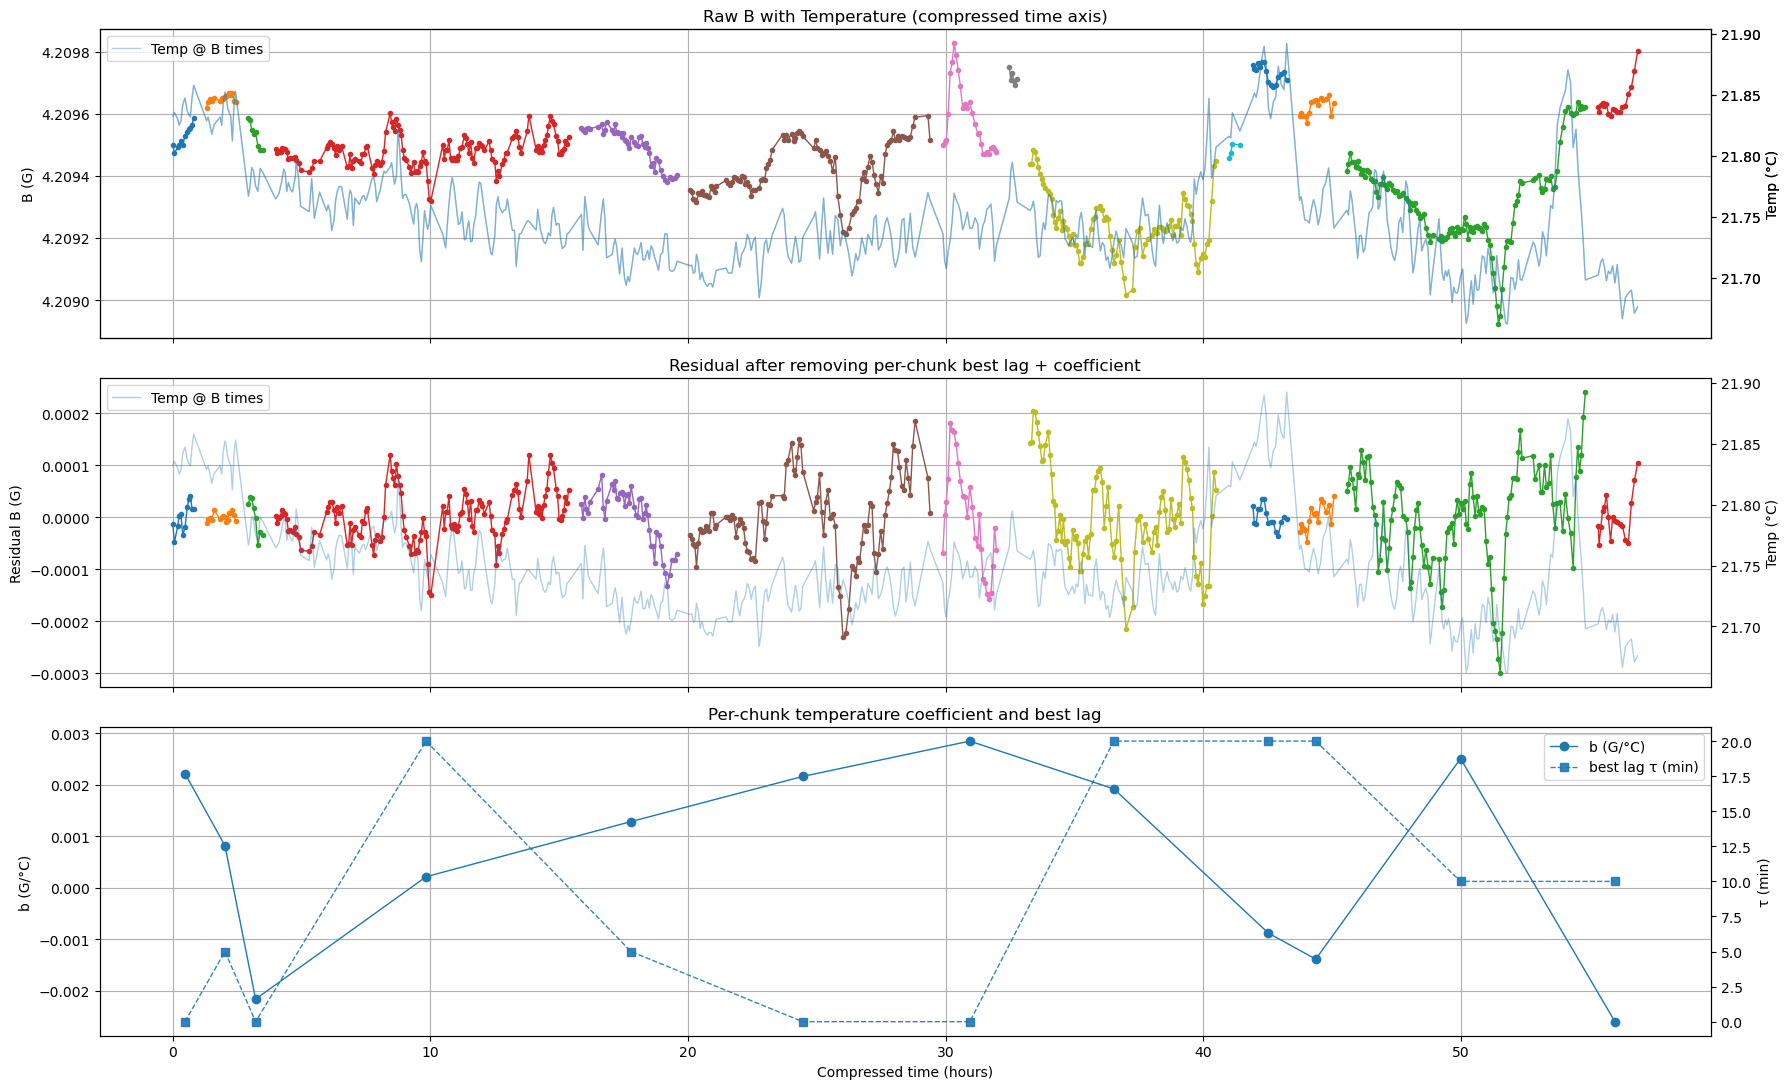

In [1]:
import os, re, json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ==========================
# Settings
# ==========================
folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

temp_base_folder_default = r"Z:\Lab_HPT_logs\Open_air"
temp_base_folder_top_insensitive = r"Z:\Lab_HPT_logs\1762nm_box"

start_date = datetime(2026, 2, 19, 16, 0, 0)
end_date   = datetime(2026, 12, 15, 0, 0, 0)

USE_TOP_TEMP_FOR_B = False
TEMP_BIN_MINUTES = 5

GAP_THRESHOLD_MIN = 30   # split segments if gap > this

# Per-segment lag scan
LAG_STEP_MIN = 5
MAX_LAG_MIN  = 20
MIN_POINTS_PER_SEGMENT = 8

# ==========================
# Temperature loading helpers
# ==========================
temp_line_pattern = re.compile(
    r"^(?P<time>\d{2}:\d{2}:\d{2})\s*-\s*.*?\bAvg Temp:\s*(?P<temp>[-+]?\d*\.?\d+)"
)
temperature_cache = {}

def load_temperature_for_day(day_dt, base_folder):
    cache_key = (base_folder, day_dt.date())
    if cache_key in temperature_cache:
        return temperature_cache[cache_key]

    month_dir = os.path.join(base_folder, day_dt.strftime("%Y_%m"))
    day_stem = day_dt.strftime("%Y_%m_%d")
    day_candidates = [
        os.path.join(month_dir, day_stem),
        os.path.join(month_dir, f"{day_stem}.txt"),
    ]

    day_file = next((path for path in day_candidates if os.path.isfile(path)), None)
    if day_file is None:
        temperature_cache[cache_key] = ([], [])
        return temperature_cache[cache_key]

    day_times, day_temps = [], []
    with open(day_file, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            match = temp_line_pattern.search(line.strip())
            if not match:
                continue
            try:
                sample_time = datetime.strptime(match.group("time"), "%H:%M:%S").time()
                sample_dt = datetime.combine(day_dt.date(), sample_time)
                sample_temp = float(match.group("temp"))
            except ValueError:
                continue
            day_times.append(sample_dt)
            day_temps.append(sample_temp)

    if day_times:
        paired = sorted(zip(day_times, day_temps), key=lambda x: x[0])
        day_times, day_temps = map(list, zip(*paired))

    temperature_cache[cache_key] = (day_times, day_temps)
    return temperature_cache[cache_key]

def load_temperature_series(start_dt, end_dt, base_folder):
    all_times, all_temps = [], []
    current_day = start_dt.date()
    last_day = end_dt.date()
    while current_day <= last_day:
        day_dt = datetime.combine(current_day, datetime.min.time())
        day_times, day_temps = load_temperature_for_day(day_dt, base_folder)
        for t, temp in zip(day_times, day_temps):
            if start_dt <= t <= end_dt:
                all_times.append(t)
                all_temps.append(temp)
        current_day += timedelta(days=1)
    return np.array(all_times, dtype=object), np.array(all_temps, dtype=float)

def bin_temperature_series(temp_times, temp_values, bin_minutes=None):
    if bin_minutes is None or temp_values.size == 0:
        return temp_times, temp_values
    bins = {}
    for t, temp in zip(temp_times, temp_values):
        floored_minute = (t.minute // bin_minutes) * bin_minutes
        bin_dt = t.replace(minute=floored_minute, second=0, microsecond=0)
        bins.setdefault(bin_dt, []).append(float(temp))
    binned_times = sorted(bins.keys())
    binned_values = [np.mean(bins[bt]) for bt in binned_times]
    return np.array(binned_times, dtype=object), np.array(binned_values, dtype=float)

# ==========================
# B-field reading
# ==========================
def read_B_time_series(folder_paths, start_date, end_date):
    file_times, list_freqs = [], []
    for folder_path in folder_paths:
        if not os.path.isdir(folder_path):
            print(f"Skipping missing folder: {folder_path}")
            continue
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            if not os.path.isfile(file_path):
                continue
            mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))
            if not (start_date <= mod_time <= end_date):
                continue
            with open(file_path, "r") as f:
                try:
                    lines = f.readlines()
                    top_list = json.loads(lines[0].strip())
                except (IndexError, json.JSONDecodeError):
                    continue
            if len(top_list) > 1:
                file_times.append(mod_time)
                list_freqs.append(top_list)

    if not file_times:
        return [], np.array([])

    times, freqs = zip(*sorted(zip(file_times, list_freqs), key=lambda x: x[0]))
    f0 = np.array([ff[0] for ff in freqs], dtype=float)
    f1 = np.array([ff[1] for ff in freqs], dtype=float)

    B = (f1 - f0) / (-3.498)
    B = 4.2095 + B - B[0]
    return list(times), B

def to_epoch_seconds(dts):
    return np.array([dt.timestamp() for dt in dts], dtype=float)

# ==========================
# Segmenting + compressed time axis
# ==========================
def split_segments(times_dt, gap_threshold_min):
    t = to_epoch_seconds(times_dt)
    gap_thr = gap_threshold_min * 60.0
    segs = []
    start = 0
    for i in range(1, len(t)):
        if (t[i] - t[i-1]) > gap_thr:
            segs.append((start, i))
            start = i
    segs.append((start, len(t)))
    return segs

def compressed_time_axis(times_dt, gap_threshold_minutes=30):
    t = to_epoch_seconds(times_dt)
    if len(t) == 0:
        return np.array([])
    gap_thr = gap_threshold_minutes * 60.0
    x = np.zeros_like(t)
    offset = 0.0
    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        if dt > gap_thr:
            offset += (dt - gap_thr)
        x[i] = (t[i] - t[0]) - offset
    return x

# ==========================
# Temperature interpolation + per-segment best lag fit
# ==========================
def interp_temperature(temp_times, temp_vals, query_times_epoch):
    if len(temp_vals) < 2:
        return np.full_like(query_times_epoch, np.nan, dtype=float)
    tT = to_epoch_seconds(list(temp_times))
    return np.interp(query_times_epoch, tT, temp_vals)

def fit_line(y, x):
    """Fit y ≈ a + b x. Returns a,b,r2."""
    mask = np.isfinite(y) & np.isfinite(x)
    yv = y[mask]
    xv = x[mask]
    if len(yv) < 3:
        return np.nan, np.nan, -np.inf
    X = np.column_stack([np.ones(len(xv)), xv])
    beta, *_ = np.linalg.lstsq(X, yv, rcond=None)
    a, b = beta
    yhat = a + b * xv
    ss_res = np.sum((yv - yhat) ** 2)
    ss_tot = np.sum((yv - np.mean(yv)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else -np.inf
    return float(a), float(b), float(r2)

def best_lag_fit_segment(t_seg, B_seg, temp_times, temp_vals, lags_min):
    best = {"r2": -np.inf, "lag_min": np.nan, "a": np.nan, "b": np.nan}
    for lag_min in lags_min:
        T_lag = interp_temperature(temp_times, temp_vals, t_seg - lag_min * 60.0)
        a, b, r2 = fit_line(B_seg, T_lag)
        if r2 > best["r2"]:
            best.update({"r2": r2, "lag_min": float(lag_min), "a": a, "b": b})
    return best

# ==========================
# Main
# ==========================
times_B, B = read_B_time_series(folder_paths, start_date, end_date)
print("Measured B points:", len(B))
if len(B) < 10:
    raise SystemExit("Not enough B points in range.")

temp_folder = temp_base_folder_top_insensitive if USE_TOP_TEMP_FOR_B else temp_base_folder_default
temp_times, temp_vals = load_temperature_series(times_B[0], times_B[-1], temp_folder)
temp_times, temp_vals = bin_temperature_series(temp_times, temp_vals, TEMP_BIN_MINUTES)
print("Temperature points:", len(temp_vals))

tB = to_epoch_seconds(times_B)
T_at_B = interp_temperature(temp_times, temp_vals, tB)

x = compressed_time_axis(times_B, GAP_THRESHOLD_MIN)
segs = split_segments(times_B, GAP_THRESHOLD_MIN)
lags_min = np.arange(0, MAX_LAG_MIN + 0.1, LAG_STEP_MIN)

# piecewise residual based on per-segment best lag+coeff
B_fit_piece = np.full_like(B, np.nan, dtype=float)

seg_mid_x_hr = []
seg_b = []
seg_tau = []

for (i0, i1) in segs:
    if (i1 - i0) < MIN_POINTS_PER_SEGMENT:
        continue

    t_seg = tB[i0:i1]
    B_seg = B[i0:i1]

    fit = best_lag_fit_segment(t_seg, B_seg, temp_times, temp_vals, lags_min)

    tau = fit["lag_min"]
    a = fit["a"]
    b = fit["b"]

    # predicted B in this segment
    T_lag = interp_temperature(temp_times, temp_vals, t_seg - tau * 60.0)
    B_fit_piece[i0:i1] = a + b * T_lag

    mid_idx = (i0 + i1) // 2
    seg_mid_x_hr.append(x[mid_idx] / 3600.0)
    seg_b.append(b)
    seg_tau.append(tau)

B_resid = B - B_fit_piece

# ==========================
# Plot
# ==========================
fig, ax = plt.subplots(3, 1, figsize=(18, 11), sharex=True)

# 1) Raw B + Temp
# Raw B, each segment a different color
for s, (i0, i1) in enumerate(segs):
    ax[0].plot(x[i0:i1]/3600.0, B[i0:i1], "o-", markersize=3, linewidth=1)

# Temperature overlaid (not chunked)
ax0t = ax[0].twinx()
ax0t.plot(x/3600.0, T_at_B, "-", alpha=0.35, linewidth=1, label="Temp @ B times")

ax[0].set_ylabel("B (G)")
ax0t.set_ylabel("Temp (°C)")
ax[0].grid(True)
ax[0].set_title("Raw B by chunk + Temperature")
ax[0].set_ylabel("B (G)")
ax[0].set_title("Raw B with Temperature (compressed time axis)")
ax[0].grid(True)
ax0t = ax[0].twinx()
ax0t.plot(x/3600.0, T_at_B, "-", alpha=0.35, linewidth=1, label="Temp @ B times")
ax0t.set_ylabel("Temp (°C)")

# 2) Residual + Temp
for s, (i0, i1) in enumerate(segs):
    ax[1].plot(x[i0:i1]/3600.0, B_resid[i0:i1], "o-", markersize=3, linewidth=1)

ax[1].set_ylabel("Residual B (G)")
ax[1].set_title("Residual after removing per-chunk best lag + coefficient")
ax[1].grid(True)
ax1t = ax[1].twinx()
ax1t.plot(x/3600.0, T_at_B, "-", alpha=0.35, linewidth=1, label="Temp @ B times")
ax1t.set_ylabel("Temp (°C)")

# 3) b and tau vs time (per segment)
seg_mid_x_hr = np.array(seg_mid_x_hr, dtype=float)
seg_b = np.array(seg_b, dtype=float)
seg_tau = np.array(seg_tau, dtype=float)

ax[2].plot(seg_mid_x_hr, seg_b, "o-", linewidth=1, label="b (G/°C)")
ax[2].set_ylabel("b (G/°C)")
ax[2].set_title("Per-chunk temperature coefficient and best lag")
ax[2].grid(True)
ax2t = ax[2].twinx()
ax2t.plot(seg_mid_x_hr, seg_tau, "s--", linewidth=1, alpha=0.9, label="best lag τ (min)")
ax2t.set_ylabel("τ (min)")
ax[2].set_xlabel("Compressed time (hours)")

# Legends (combine each subplot’s left+right)
l0, lab0 = ax[0].get_legend_handles_labels()
l0t, lab0t = ax0t.get_legend_handles_labels()
ax[0].legend(l0 + l0t, lab0 + lab0t, loc="best")

l1, lab1 = ax[1].get_legend_handles_labels()
l1t, lab1t = ax1t.get_legend_handles_labels()
ax[1].legend(l1 + l1t, lab1 + lab1t, loc="best")

l2, lab2 = ax[2].get_legend_handles_labels()
l2t, lab2t = ax2t.get_legend_handles_labels()
ax[2].legend(l2 + l2t, lab2 + lab2t, loc="best")

plt.tight_layout()
plt.savefig("B_raw_residual_and_chunk_coeff_lag.png", dpi=200)
plt.show()

# Allan Deivation 

Measured B points: 619


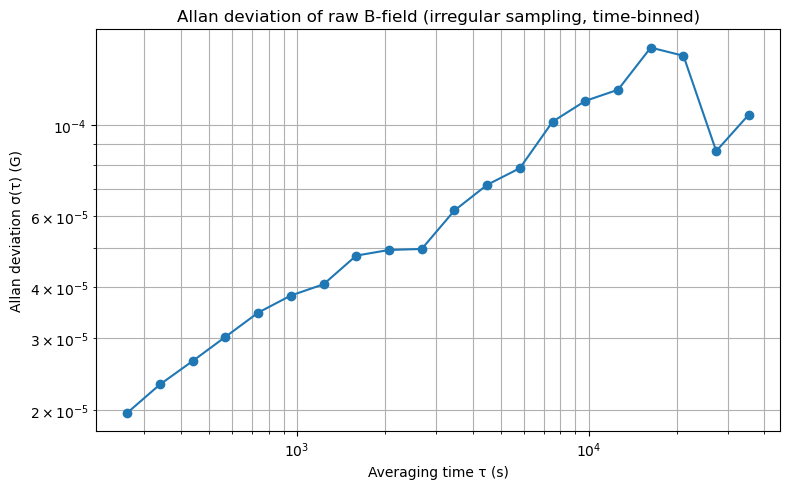

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes you already have:
# - times_B : list of datetime objects (UNCOMPRESSED times)
# - B       : np.array of raw B-field values (same length)

def to_epoch_seconds(dts):
    return np.array([dt.timestamp() for dt in dts], dtype=float)

def allan_deviation_irregular(t, y, m_values=None, min_bins=8):
    """
    Allan deviation for irregularly sampled data by time-binning.
    For each averaging time tau, bin points into consecutive tau-wide bins,
    compute bin means, then compute Allan deviation from successive means.

    t: epoch seconds (ascending)
    y: values
    m_values: list/array of integer bin widths in multiples of base_tau
              (if None, uses log-spaced taus directly)
    min_bins: require at least this many bins to compute a point
    Returns taus (sec), adev
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    # drop NaNs
    # mask = np.isfinite(t) & np.isfinite(y)
    # t = t[mask]
    # y = y[mask]
    if len(t) < 10:
        return np.array([]), np.array([])

    # ensure sorted
    idx = np.argsort(t)
    t = t[idx]
    y = y[idx]

    # choose candidate taus (seconds) on a log grid based on the data span
    span = t[-1] - t[0]
    dt_med = np.median(np.diff(t))
    if not np.isfinite(dt_med) or dt_med <= 0:
        dt_med = 1.0

    # taus from ~1*dt_med up to ~span/10
    tau_min = dt_med
    tau_max = max(dt_med * 2, span / 10.0)
    taus = np.unique(np.logspace(np.log10(tau_min), np.log10(tau_max), 20))

    adev = []
    taus_used = []

    for tau in taus:
        # bin index for each sample
        k = np.floor((t - t[0]) / tau).astype(int)

        # compute mean per bin (only bins that have at least 1 point)
        # (vectorized via bincount)
        kmax = k.max()
        counts = np.bincount(k, minlength=kmax + 1).astype(float)
        sums = np.bincount(k, weights=y, minlength=kmax + 1)
        with np.errstate(invalid="ignore", divide="ignore"):
            means = sums / counts
        means[counts == 0] = np.nan

        valid_adj = np.isfinite(means[:-1]) & np.isfinite(means[1:])
        dy = means[1:][valid_adj] - means[:-1][valid_adj]
        if dy.size < 1:
            continue
        sigma2 = 0.5 * np.mean(dy**2)
        adev.append(np.sqrt(sigma2))
        taus_used.append(tau)

    return np.array(taus_used), np.array(adev)

# ---- run ----

folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

start_date = datetime(2026, 2, 19, 16, 0, 0)
end_date   = datetime(2026, 12, 15, 0, 0, 0)
times_B, B = read_B_time_series(folder_paths, start_date, end_date)
print("Measured B points:", len(B))
t = to_epoch_seconds(times_B)

taus, adev = allan_deviation_irregular(t, B)
# taus, adev = allan_deviation_irregular(x, B_resid)



plt.figure(figsize=(8, 5))
if len(taus) == 0:
    plt.text(0.1, 0.5, "Not enough data to compute Allan deviation", fontsize=12)
else:
    plt.loglog(taus, adev, "o-")
    plt.xlabel("Averaging time τ (s)")
    plt.ylabel("Allan deviation σ(τ) (G)")
    plt.title("Allan deviation of raw B-field (irregular sampling, time-binned)")
    plt.grid(True, which="both")
plt.tight_layout()
plt.show()

In [4]:
for i, (tau, sigma) in enumerate(zip(taus, adev)):
    print(f"τ={tau:.1f} s: σ(τ)={sigma:.3g} G")

τ=262.2 s: σ(τ)=1.97e-05 G
τ=339.4 s: σ(τ)=2.31e-05 G
τ=439.4 s: σ(τ)=2.64e-05 G
τ=568.8 s: σ(τ)=3.02e-05 G
τ=736.3 s: σ(τ)=3.47e-05 G
τ=953.2 s: σ(τ)=3.82e-05 G
τ=1233.9 s: σ(τ)=4.07e-05 G
τ=1597.3 s: σ(τ)=4.79e-05 G
τ=2067.8 s: σ(τ)=4.95e-05 G
τ=2676.7 s: σ(τ)=4.97e-05 G
τ=3465.1 s: σ(τ)=6.18e-05 G
τ=4485.6 s: σ(τ)=7.15e-05 G
τ=5806.6 s: σ(τ)=7.86e-05 G
τ=7516.8 s: σ(τ)=0.000102 G
τ=9730.6 s: σ(τ)=0.000115 G
τ=12596.3 s: σ(τ)=0.000122 G
τ=16306.1 s: σ(τ)=0.000155 G
τ=21108.5 s: σ(τ)=0.000148 G
τ=27325.2 s: σ(τ)=8.65e-05 G
τ=35372.9 s: σ(τ)=0.000106 G


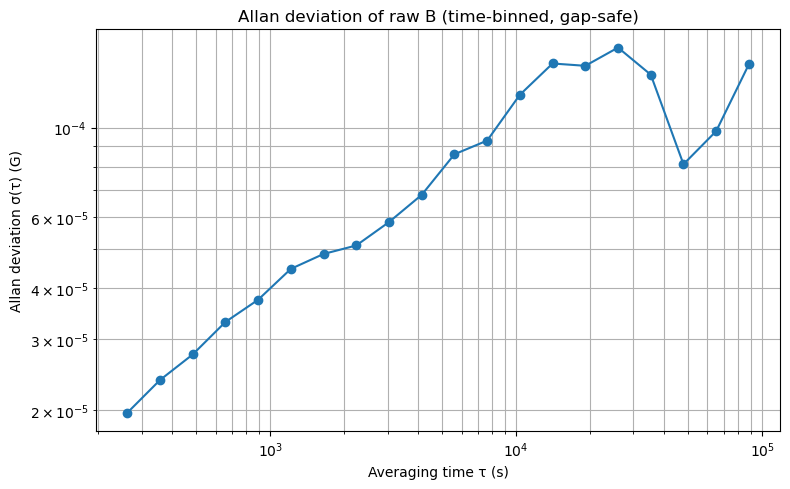

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def allan_time_binned(meas_times, y,
                      n_taus=20,
                      min_tau_floor=1.0,
                      max_tau_fraction=0.25):
    """
    Allan deviation for irregular sampling using non-overlapping time bins.
    - Bins of width tau starting at t0
    - Computes mean in each bin
    - Uses ONLY adjacent bin pairs where both bins are non-empty
    Returns: allan_tau (sec), allan_dev
    """
    t_sec = np.array([(mt - meas_times[0]).total_seconds() for mt in meas_times], dtype=float)
    y = np.asarray(y, dtype=float)

    # drop NaNs and sort by time
    mask = np.isfinite(t_sec) & np.isfinite(y)
    t_sec = t_sec[mask]
    y = y[mask]
    idx = np.argsort(t_sec)
    t_sec = t_sec[idx]
    y = y[idx]

    if t_sec.size < 3:
        return np.array([]), np.array([])

    # basic time spacing estimate (median of positive diffs)
    dt = np.diff(t_sec)
    positive_dt = dt[dt > 0]
    if positive_dt.size == 0:
        raise ValueError("Insufficient time resolution for Allan calc")

    min_tau = max(np.median(positive_dt), float(min_tau_floor))
    total_T = t_sec.max() - t_sec.min()
    max_tau = max(total_T * float(max_tau_fraction), min_tau)

    if max_tau <= min_tau:
        taus = np.array([min_tau], dtype=float)
    else:
        taus = np.unique(np.logspace(np.log10(min_tau), np.log10(max_tau), n_taus))

    allan_tau = []
    allan_dev = []

    for tau in taus:
        t0 = t_sec[0]
        edges = np.arange(t0, t_sec[-1] + tau, tau)
        if edges.size < 3:
            continue

        bin_means = np.full(edges.size - 1, np.nan, dtype=float)

        # Compute mean per bin
        for i in range(edges.size - 1):
            m = (t_sec >= edges[i]) & (t_sec < edges[i + 1])
            if np.any(m):
                bin_means[i] = np.mean(y[m])

        # Adjacent differences only where both bins valid
        valid_adj = np.isfinite(bin_means[:-1]) & np.isfinite(bin_means[1:])
        diffs = bin_means[1:][valid_adj] - bin_means[:-1][valid_adj]
        if diffs.size < 1:
            continue

        var = 0.5 * np.mean(diffs ** 2)
        allan_tau.append(tau)
        allan_dev.append(np.sqrt(var))

    return np.array(allan_tau, dtype=float), np.array(allan_dev, dtype=float)

# ---- Use it (assumes you have times_B and B) ----
allan_tau, allan_dev = allan_time_binned(times_B, B, n_taus=20)

plt.figure(figsize=(8, 5))
if allan_tau.size == 0:
    plt.text(0.1, 0.5, "Not enough valid bins/pairs to compute Allan deviation", fontsize=12)
else:
    plt.loglog(allan_tau, allan_dev, "o-")
    plt.xlabel("Averaging time τ (s)")
    plt.ylabel("Allan deviation σ(τ) (G)")
    plt.title("Allan deviation of raw B (time-binned, gap-safe)")
    plt.grid(True, which="both")
plt.tight_layout()
plt.show()

In [6]:
for i, (tau, sigma) in enumerate(zip(allan_tau, allan_dev)):
    print(f"τ={tau:.1f} s: σ(τ)={sigma:.3g} G")

τ=262.2 s: σ(τ)=1.97e-05 G
τ=356.2 s: σ(τ)=2.37e-05 G
τ=483.9 s: σ(τ)=2.74e-05 G
τ=657.4 s: σ(τ)=3.3e-05 G
τ=893.0 s: σ(τ)=3.75e-05 G
τ=1213.1 s: σ(τ)=4.47e-05 G
τ=1648.0 s: σ(τ)=4.87e-05 G
τ=2238.7 s: σ(τ)=5.11e-05 G
τ=3041.2 s: σ(τ)=5.84e-05 G
τ=4131.5 s: σ(τ)=6.82e-05 G
τ=5612.5 s: σ(τ)=8.59e-05 G
τ=7624.4 s: σ(τ)=9.29e-05 G
τ=10357.5 s: σ(τ)=0.000121 G
τ=14070.4 s: σ(τ)=0.000144 G
τ=19114.2 s: σ(τ)=0.000142 G
τ=25966.1 s: σ(τ)=0.000158 G
τ=35274.3 s: σ(τ)=0.000135 G
τ=47919.1 s: σ(τ)=8.12e-05 G
τ=65096.8 s: σ(τ)=9.8e-05 G
τ=88432.2 s: σ(τ)=0.000143 G


# PDF

Files processed: 620
Total slopes possible: 619
Slopes kept (dt <= 30 min): 606
Slopes skipped (gaps or nonpositive dt): 13


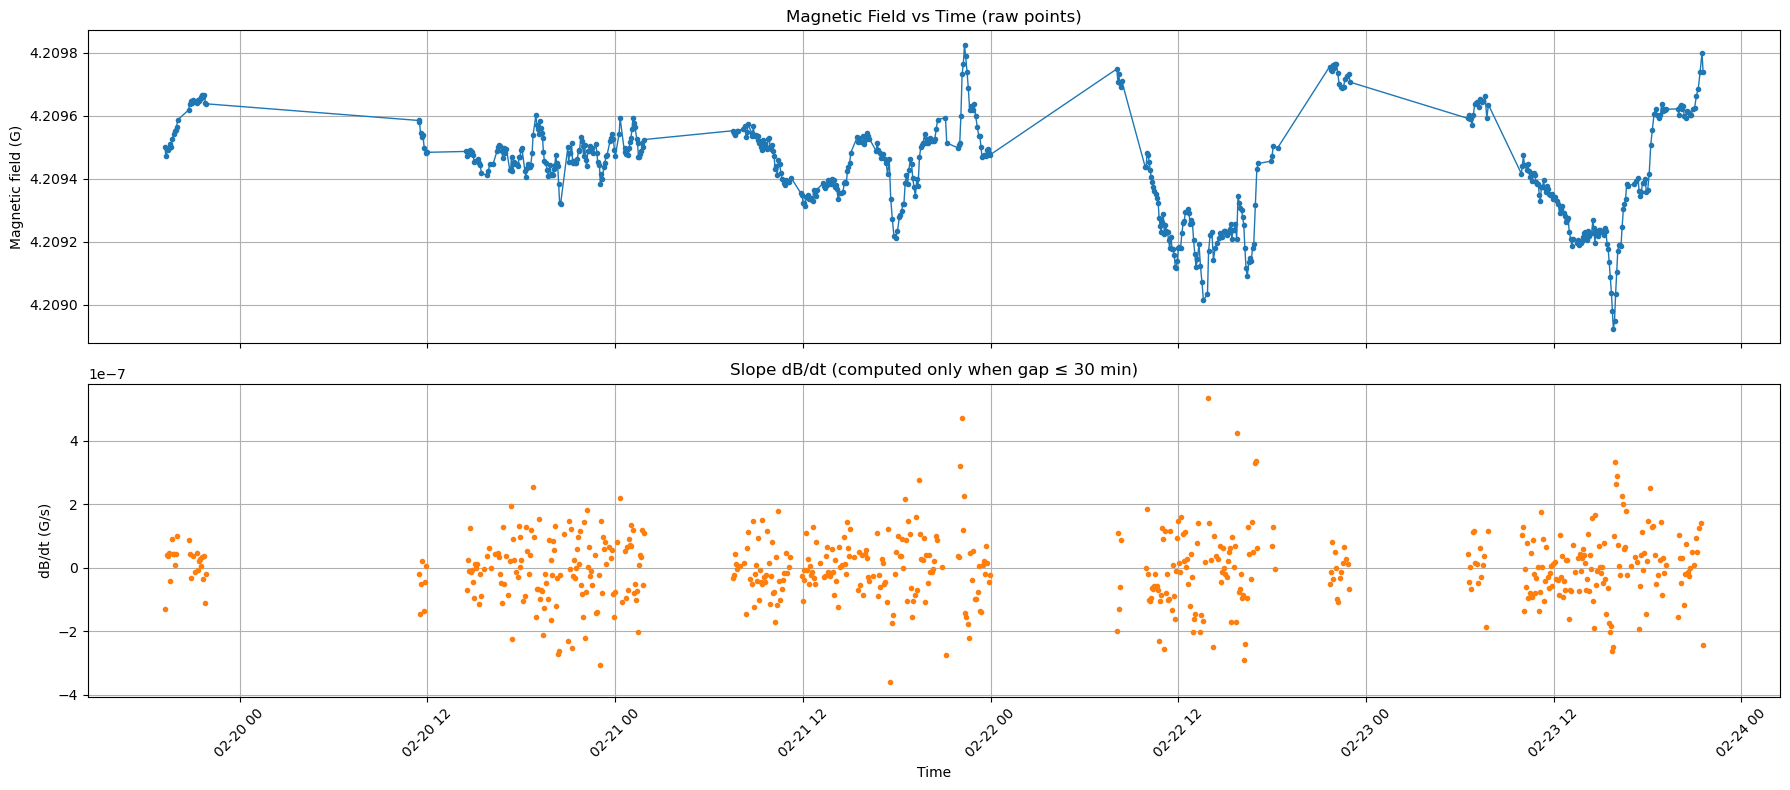

In [7]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# -----------------------
# Settings
# -----------------------
folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

start_date = datetime(2026, 2, 19, 16, 0, 0)
end_date   = datetime(2026, 12, 15, 0, 0, 59)

GAP_THRESHOLD_MIN = 30  # if time between points > 30 min, do NOT compute slope across it

# -----------------------
# Read B-field time series
# -----------------------
file_times = []
list_freqs = []

for folder_path in folder_paths:
    if not os.path.isdir(folder_path):
        print(f"Skipping missing folder: {folder_path}")
        continue

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if not os.path.isfile(file_path):
            continue

        mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))
        if not (start_date <= mod_time <= end_date):
            continue

        with open(file_path, "r") as f:
            try:
                lines = f.readlines()
                top_list = json.loads(lines[0].strip())
            except (IndexError, json.JSONDecodeError):
                continue

        if isinstance(top_list, list) and len(top_list) > 1:
            file_times.append(mod_time)
            list_freqs.append(top_list)

print("Files processed:", len(file_times))

# Sort by time
sorted_data = sorted(zip(file_times, list_freqs), key=lambda x: x[0])
if not sorted_data:
    raise SystemExit("No valid data points found in the selected date range.")

sorted_times, sorted_freqs = zip(*sorted_data)
sorted_times = list(sorted_times)

# Extract frequencies
f0 = np.array([freq[0] for freq in sorted_freqs], dtype=float)
f1 = np.array([freq[1] for freq in sorted_freqs], dtype=float)

# Compute B-field (your formula)
B = (f1 - f0) / (-3.498)
B = 4.2095 + B - B[0]

# -----------------------
# Compute slopes dB/dt, skipping gaps > 30 min
# -----------------------
t_sec = np.array([(t - sorted_times[0]).total_seconds() for t in sorted_times], dtype=float)
dt = np.diff(t_sec)
dB = np.diff(B)

gap_thr_sec = GAP_THRESHOLD_MIN * 60.0
valid = (dt > 0) & (dt <= gap_thr_sec)  # keep only slopes within the gap threshold

# slopes list (only valid)
dB_dt = np.full_like(dt, np.nan, dtype=float)  # length N-1; NaN where skipped
dB_dt[valid] = dB[valid] / dt[valid]

# for plotting slopes vs time, use midpoints
t_mid = 0.5 * (t_sec[:-1] + t_sec[1:])

print(f"Total slopes possible: {len(dt)}")
print(f"Slopes kept (dt <= {GAP_THRESHOLD_MIN} min): {np.sum(valid)}")
print(f"Slopes skipped (gaps or nonpositive dt): {np.sum(~valid)}")

# -----------------------
# Plot only B-field + slopes (optional)
# -----------------------
fig, ax = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

ax[0].plot(sorted_times, B, "o-", markersize=3, linewidth=1)
ax[0].set_ylabel("Magnetic field (G)")
ax[0].set_title("Magnetic Field vs Time (raw points)")
ax[0].grid(True)

# Plot slopes where valid (skip NaNs automatically)
ax[1].plot([sorted_times[0] + (datetime.fromtimestamp(0) - datetime.fromtimestamp(0))]*0)  # no-op, keeps axis happy
ax[1].plot([sorted_times[0] + np.timedelta64(int(s), 's') for s in t_mid[np.isfinite(dB_dt)]],
           dB_dt[np.isfinite(dB_dt)],
           "o", markersize=3)

ax[1].set_ylabel("dB/dt (G/s)")
ax[1].set_title(f"Slope dB/dt (computed only when gap ≤ {GAP_THRESHOLD_MIN} min)")
ax[1].grid(True)

ax[1].set_xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Standard deviation of slopes (after clipping): 9.317587682810151e-08 mG/s
Voigt fit (in plotted units):
  center x0    = -0.762963
  sigma        = 59.7555  (Gaussian FWHM ~ 140.713)
  gamma (HWHM) = 41.0696  (Lorentz FWHM  ~ 82.1392)
  Voigt FWHM   ≈ 189.725 mG/s

(Units shown are mG/min if SCALE=1000*60; otherwise whatever you chose.)


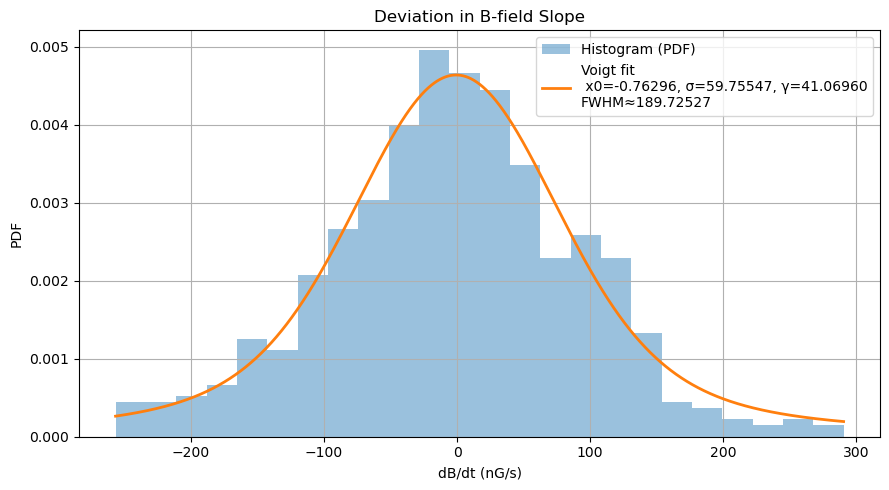

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.special import wofz

# ---- Input ----
# slopes_clip = ... (your clipped slopes)
# If you want to fit ALL valid slopes instead, use:
# slopes_clip = dB_dt[np.isfinite(dB_dt)]

# ---- Choose units for visibility/stability ----
# Convert G/s -> mG/min (often much nicer scale).

slopes = dB_dt[np.isfinite(dB_dt)] 
if slopes.size < 5:
    raise ValueError("Not enough valid slope points to plot a PDF.")

q1, q99 = np.percentile(slopes, [1, 99]) 
slopes_clip = slopes[(slopes >= q1) & (slopes <= q99)]
print('Standard deviation of slopes (after clipping):', np.std(slopes_clip), 'mG/s')
SCALE = 1e9  # mG/min per (G/s)
xdata = np.asarray(slopes_clip, dtype=float) * SCALE
xdata = xdata[np.isfinite(xdata)]
if xdata.size < 20:
    raise ValueError("Need more slope points for a stable Voigt fit.")

# ---- Histogram (empirical PDF) ----
bins = 24
hist, edges = np.histogram(xdata, bins=bins, density=True)
x = 0.5 * (edges[:-1] + edges[1:])  # bin centers
y = hist

# keep nonzero bins only (helps optimizer)
mask = y > 0
x = x[mask]
y = y[mask]

# ---- Voigt model ----
def voigt_pdf(x, amp, x0, sigma, gamma, offset):
    """
    Normalized Voigt profile times amp + offset.
    sigma: Gaussian std dev
    gamma: Lorentzian HWHM
    """
    z = ((x - x0) + 1j * gamma) / (sigma * np.sqrt(2))
    V = np.real(wofz(z)) / (sigma * np.sqrt(2*np.pi))  # normalized to area=1
    return offset + amp * V

# ---- Initial guesses ----
x0_0 = np.median(xdata)
mad = np.median(np.abs(xdata - x0_0))
sigma_0 = max(1e-12, 1.4826 * mad)   # robust std estimate
gamma_0 = max(1e-12, 0.3 * sigma_0)  # start with some Lorentz tail

offset_0 = max(0.0, 0.5 * np.min(y))
amp_0 = max(1e-12, (np.max(y) - offset_0) * sigma_0)  # scale-ish guess

p0 = [amp_0, x0_0, sigma_0, gamma_0, offset_0]

# bounds: sigma,gamma>0
lower = [0.0, np.min(xdata), 1e-15, 1e-15, 0.0]
upper = [np.inf, np.max(xdata), np.inf, np.inf, np.inf]

# ---- Fit ----
popt, pcov = curve_fit(voigt_pdf, x, y, p0=p0, bounds=(lower, upper), maxfev=50000)
amp, x0, sigma, gamma, offset = popt

# ---- FWHM (Voigt approx) ----
fwhm_g = 2.354820045 * sigma       # Gaussian FWHM
fwhm_l = 2.0 * gamma               # Lorentz FWHM
fwhm_v = 0.5346 * fwhm_l + np.sqrt(0.2166 * fwhm_l**2 + fwhm_g**2)

print("Voigt fit (in plotted units):")
print(f"  center x0    = {x0:.6g}")
print(f"  sigma        = {sigma:.6g}  (Gaussian FWHM ~ {fwhm_g:.6g})")
print(f"  gamma (HWHM) = {gamma:.6g}  (Lorentz FWHM  ~ {fwhm_l:.6g})")
print(f"  Voigt FWHM   ≈ {fwhm_v :.6g} mG/s")
print("\n(Units shown are mG/min if SCALE=1000*60; otherwise whatever you chose.)")

# ---- Plot overlay ----
xfine = np.linspace(np.min(xdata), np.max(xdata), 2000)
yfit = voigt_pdf(xfine, *popt)

plt.figure(figsize=(9, 5))
plt.hist(xdata, bins=bins, density=True, alpha=0.45, label="Histogram (PDF)")
plt.plot(xfine, yfit, linewidth=2, label=f"Voigt fit \n x0={x0:.5f}, σ={sigma:.5f}, γ={gamma:.5f}\nFWHM≈{fwhm_v:.5f}")
plt.xlabel("dB/dt (mG/min)" if SCALE == 1000.0*60.0 else "dB/dt (nG/s)")
plt.ylabel("PDF")
plt.title("Deviation in B-field Slope")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
1.03e-7 * 3.42e6 * 800e-6 * 2 

0.000563616

# Power Spectral Density

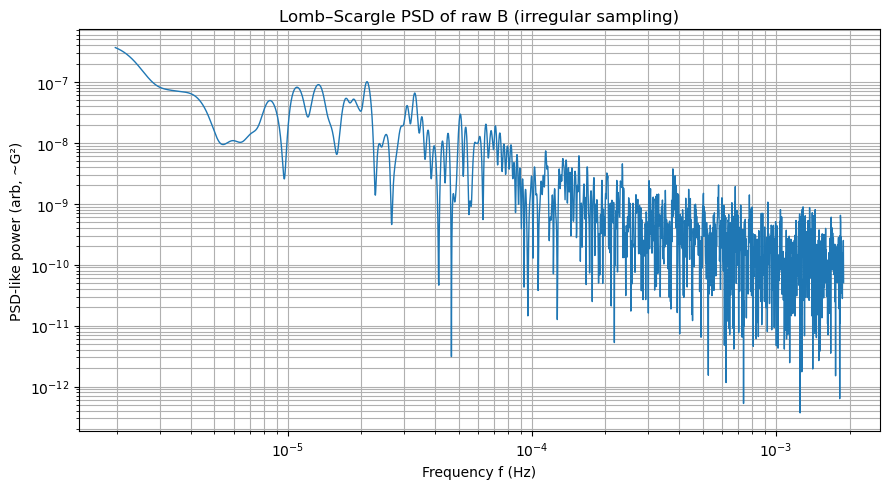

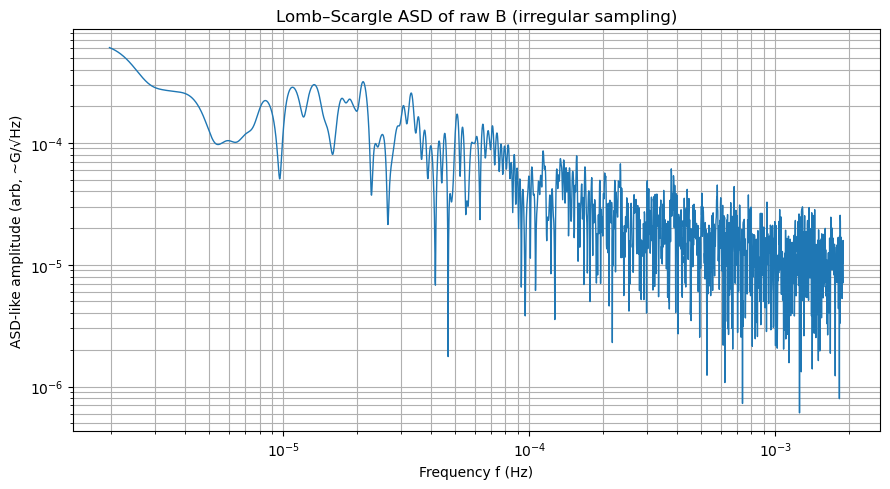

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Requires SciPy:
from scipy.signal import lombscargle

# Assumes you already have:
# times_B : list of datetime (uncompressed)
# B       : np.array raw B-field values

def to_epoch_seconds(dts):
    return np.array([dt.timestamp() for dt in dts], dtype=float)

# ---- prepare data ----
t = to_epoch_seconds(times_B)
y = np.asarray(B, dtype=float)

# drop NaNs and sort
m = np.isfinite(t) & np.isfinite(y)
t, y = t[m], y[m]
idx = np.argsort(t)
t, y = t[idx], y[idx]

# shift time to start at 0 (numerically nicer)
t = t - t[0]

# remove mean (important for Lomb–Scargle)
y = y - np.mean(y)

# ---- choose frequency grid ----
# Typical cadence (median dt) sets a reasonable upper frequency
dt_med = np.median(np.diff(t))
if not np.isfinite(dt_med) or dt_med <= 0:
    raise ValueError("Bad timestamps: non-positive dt_med")

f_min = 1.0 / (t[-1] - t[0])             # ~ one cycle over whole record
f_max = 0.5 / dt_med                     # ~ Nyquist-ish based on median dt
f_max = min(f_max, 1.0)                  # optional safety cap at 1 Hz (edit if needed)

# Log-spaced frequencies are nice for colored noise
Nf = 3000
freqs = np.logspace(np.log10(f_min), np.log10(f_max), Nf)  # Hz
omega = 2 * np.pi * freqs

# ---- Lomb–Scargle periodogram ----
# normalize=True makes it closer to a "normalized power" scale.
# We'll convert to a PSD-like scale (approx) afterward.
p = lombscargle(t, y, omega, normalize=True)

# ---- Convert to "PSD-like" units (approx) ----
# Lomb–Scargle's normalize=True returns a dimensionless normalized power.
# A common practical scaling to get something PSD-ish is:
#   S(f) ~ (2 * var(y)) * p / (effective_bandwidth)
# For plotting noise color and lines, the exact absolute scaling usually matters less.
var_y = np.var(y, ddof=1)
psd_like = 2 * var_y * p  # units ~ (G^2); relative PSD shape is what you usually trust most

# Amplitude spectral density (ASD): sqrt(PSD) ~ G / sqrt(Hz) up to scaling constants
asd_like = np.sqrt(np.maximum(psd_like, 0))

# ---- plots ----
plt.figure(figsize=(9, 5))
plt.loglog(freqs, psd_like, linewidth=1)
plt.xlabel("Frequency f (Hz)")
plt.ylabel("PSD-like power (arb, ~G²)")
plt.title("Lomb–Scargle PSD of raw B (irregular sampling)")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.loglog(freqs, asd_like, linewidth=1)
plt.xlabel("Frequency f (Hz)")
plt.ylabel("ASD-like amplitude (arb, ~G/√Hz)")
plt.title("Lomb–Scargle ASD of raw B (irregular sampling)")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()